---
title: Advanced Algorithms - Greedy Search and Greedy Randomized Adaptive Search Procedure (GRASP)
toc: true
image: image.png
execute: 
  enabled: false
---


Brute force algorithms are effective up to a certain point, but it can quickly become impossible to evaluate all possible combinations of sites as the possible number of combinations grows very quickly. 

For example, let's imagine you have 30 possible places to put a site, but you only want 1 site. That's 30 combinations to try. 

If you want 2 sites from those 30 possibilities, that's 435 combinations to try. 

3 sites from those 30 possibilities is 4060 combinations...

4 is 27,405 combinations...

5 is 142,506 combinations...

6 is 75,287,520 combinations! 

In [1]:
#| echo: false
import pandas as pd
import math

combos_df = pd.DataFrame(
    [{"n_sites_to_include": i, "total_n_sites": 30, "combinations": int(math.factorial(30)/(math.factorial(30-i) * math.factorial(i)))} for i in range(1,30)]

)

combos_df

,n_sites_to_include,total_n_sites,combinations
0,1,30,30
1,2,30,435
2,3,30,4060
3,4,30,27405
4,5,30,142506
5,6,30,593775
6,7,30,2035800
7,8,30,5852925
8,9,30,14307150
9,10,30,30045015


For our 30 site problem, if we want a total of 15 sites, we can see that's nearly 160 **million** combinations to evaluate.  

In [2]:
# echo: false
import plotly.express as px

px.bar(combos_df, x="n_sites_to_include", y="combinations")

While we can handle the memory implications of trying to evaluate that many combinations using the `keep_best_n` and `keep_worst_n` arguments in .solve() so we're not storing every single result, it's still going to take an extremely long time to evaluate that many solutions. 

Instead, we can turn to some different possible solutions, which we'll explore in these notebooks. 

## Greedy Search

Greedy search works quite simply. 

Let's imagine we wanted to find a good solution to our n=15 problem. 

We'd start by working out the best solution for 1 site (i.e. what single site gives us the best result). 

We'd then take work out the best possible combination of 2 sites - where 1 site must be the site we found from the first round. 

Then we keep going, repeating this process all the way up to the final number of sites. 

:::{.callout-note}
Because the greedy algorithm is short-sighted - it always takes the best possible next move - it will find a 'good' solution, but it may well not find the 'best' solution - or even one of the best. 

We describe this as 'getting stuck in a local optimum'. 
:::

In [3]:
from lokigi.site import SiteProblem

problem_small = SiteProblem()

problem_small.add_sites(
    "../../../sample_data/brighton_sites_named.geojson",
    candidate_id_col="site"
    )

problem_small.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem_small.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    # "../../../sample_data/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

In [4]:
solution_small_greedy = problem_small.solve(p=3, search_strategy="greedy")

C:\lokigi\lokigi\site.py:1434: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [5]
Best combination for 2 sites: [2, 5]
Best combination for 3 sites: [2, 3, 5]


In [5]:
solution_small_greedy

In [6]:
solution_small_greedy.return_best_combination_details()

,index,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,0,1,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",None,5.357941,5.357941,8.055933,16.688833,0.0,LSOA L...


<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

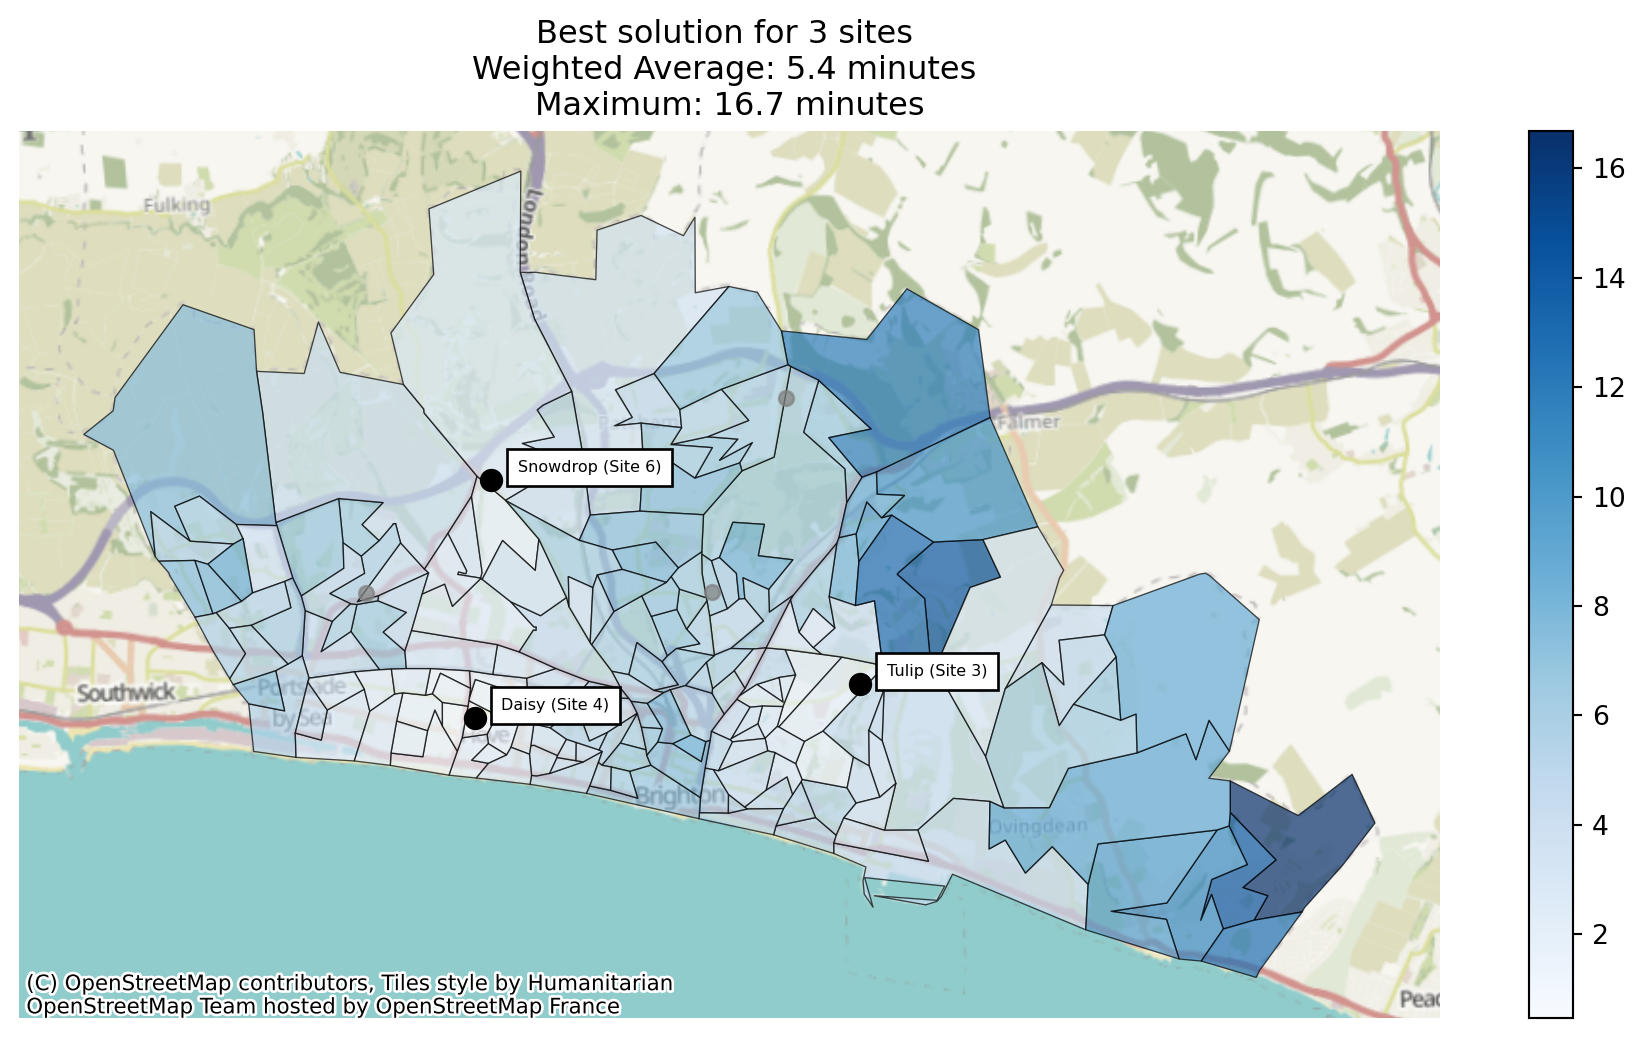

In [7]:
solution_small_greedy.plot_best_combination()

Let's now compare this with the best solution from our brute force approach. 

  0%|          | 0/20 [00:00<?, ?it/s]

<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

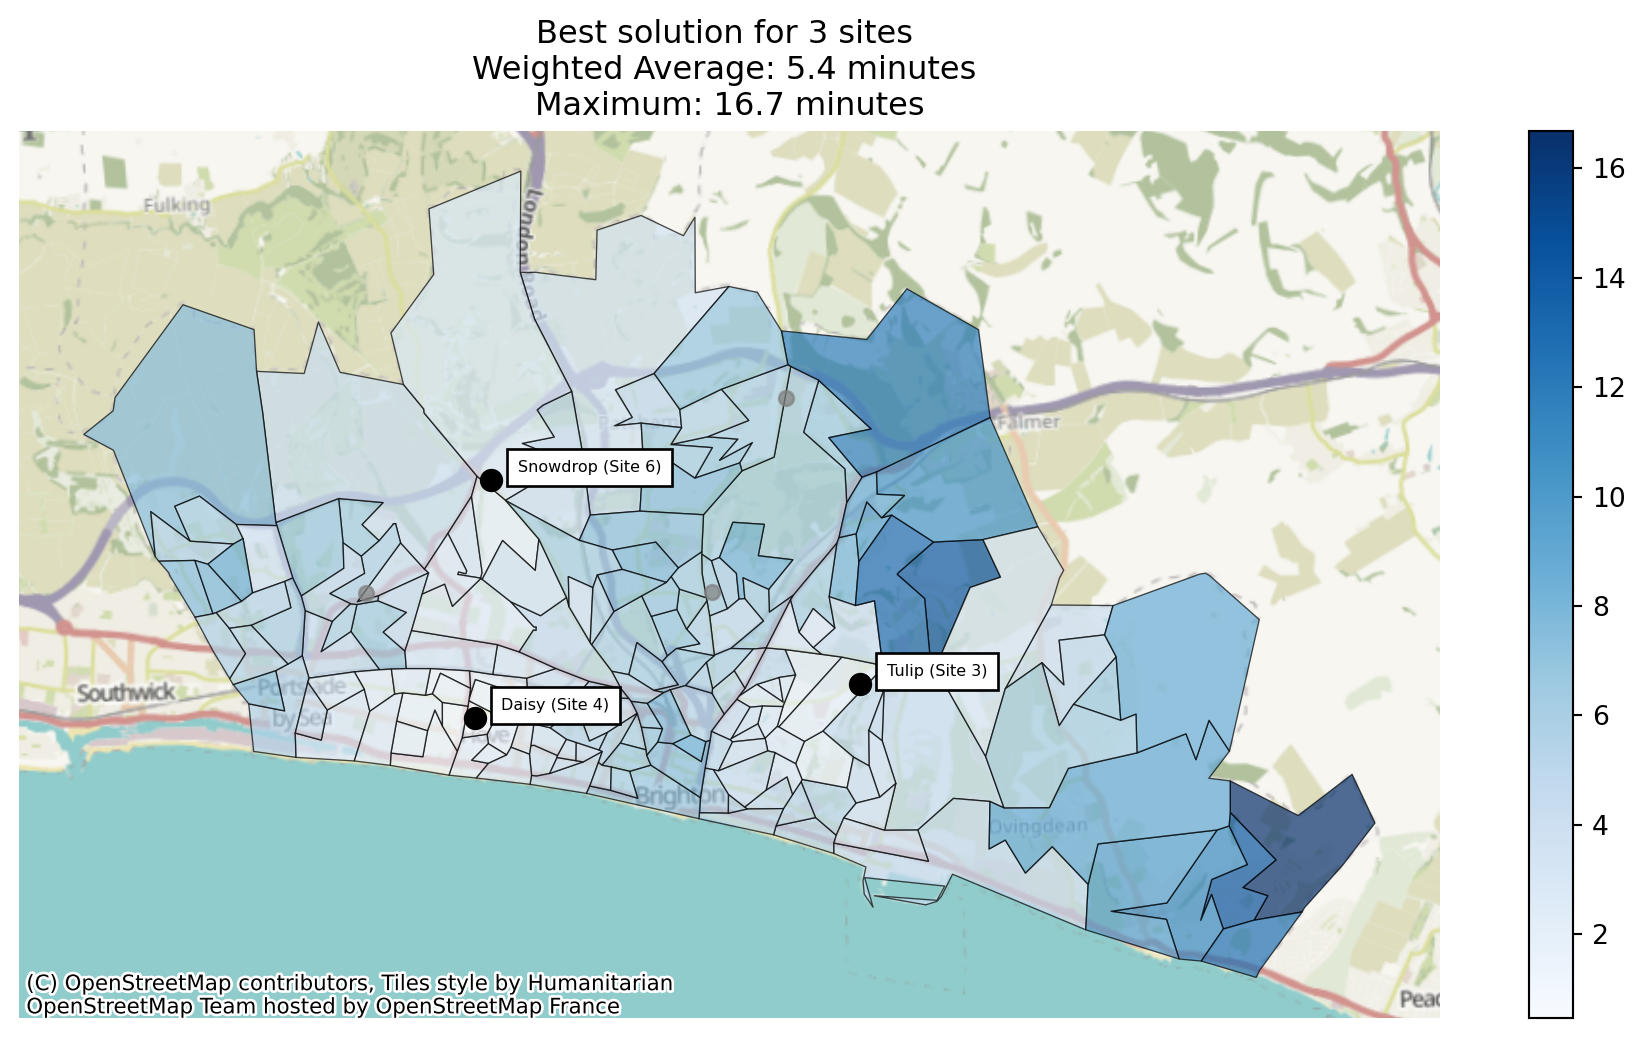

In [8]:
solution_small_brute_force = problem_small.solve(p=3, search_strategy="brute-force")
solution_small_brute_force.plot_best_combination()

Let's see if the solution differs with different objectives. 

  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [2]
Best combination for 2 sites: [2, 3]
Best combination for 3 sites: [2, 3, 5]


<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

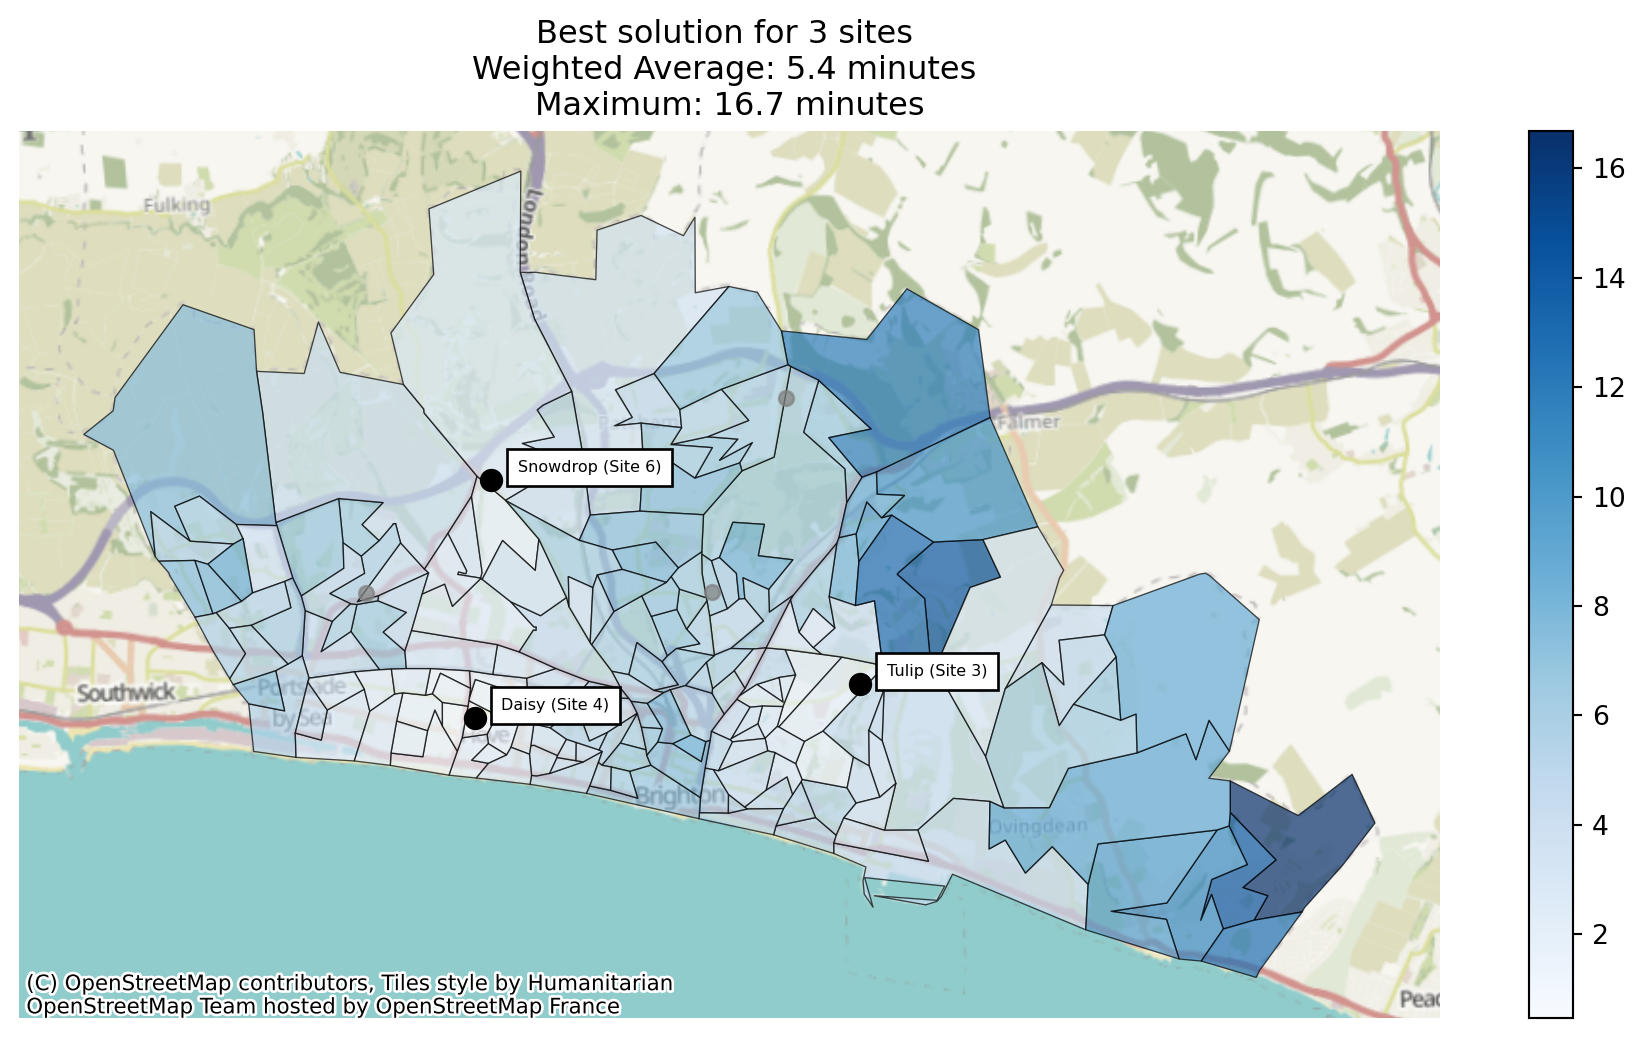

In [9]:
solution_small_greedy_p_center = problem_small.solve(p=3, search_strategy="greedy", objectives="p_center")
solution_small_greedy_p_center.plot_best_combination()

  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [5]
Best combination for 2 sites: [2, 5]
Best combination for 3 sites: [2, 3, 5]


<Axes: title={'center': 'Best solution for 3 sites \nCoverage within threshold of 8 minutes: 89.7% \nUnweighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

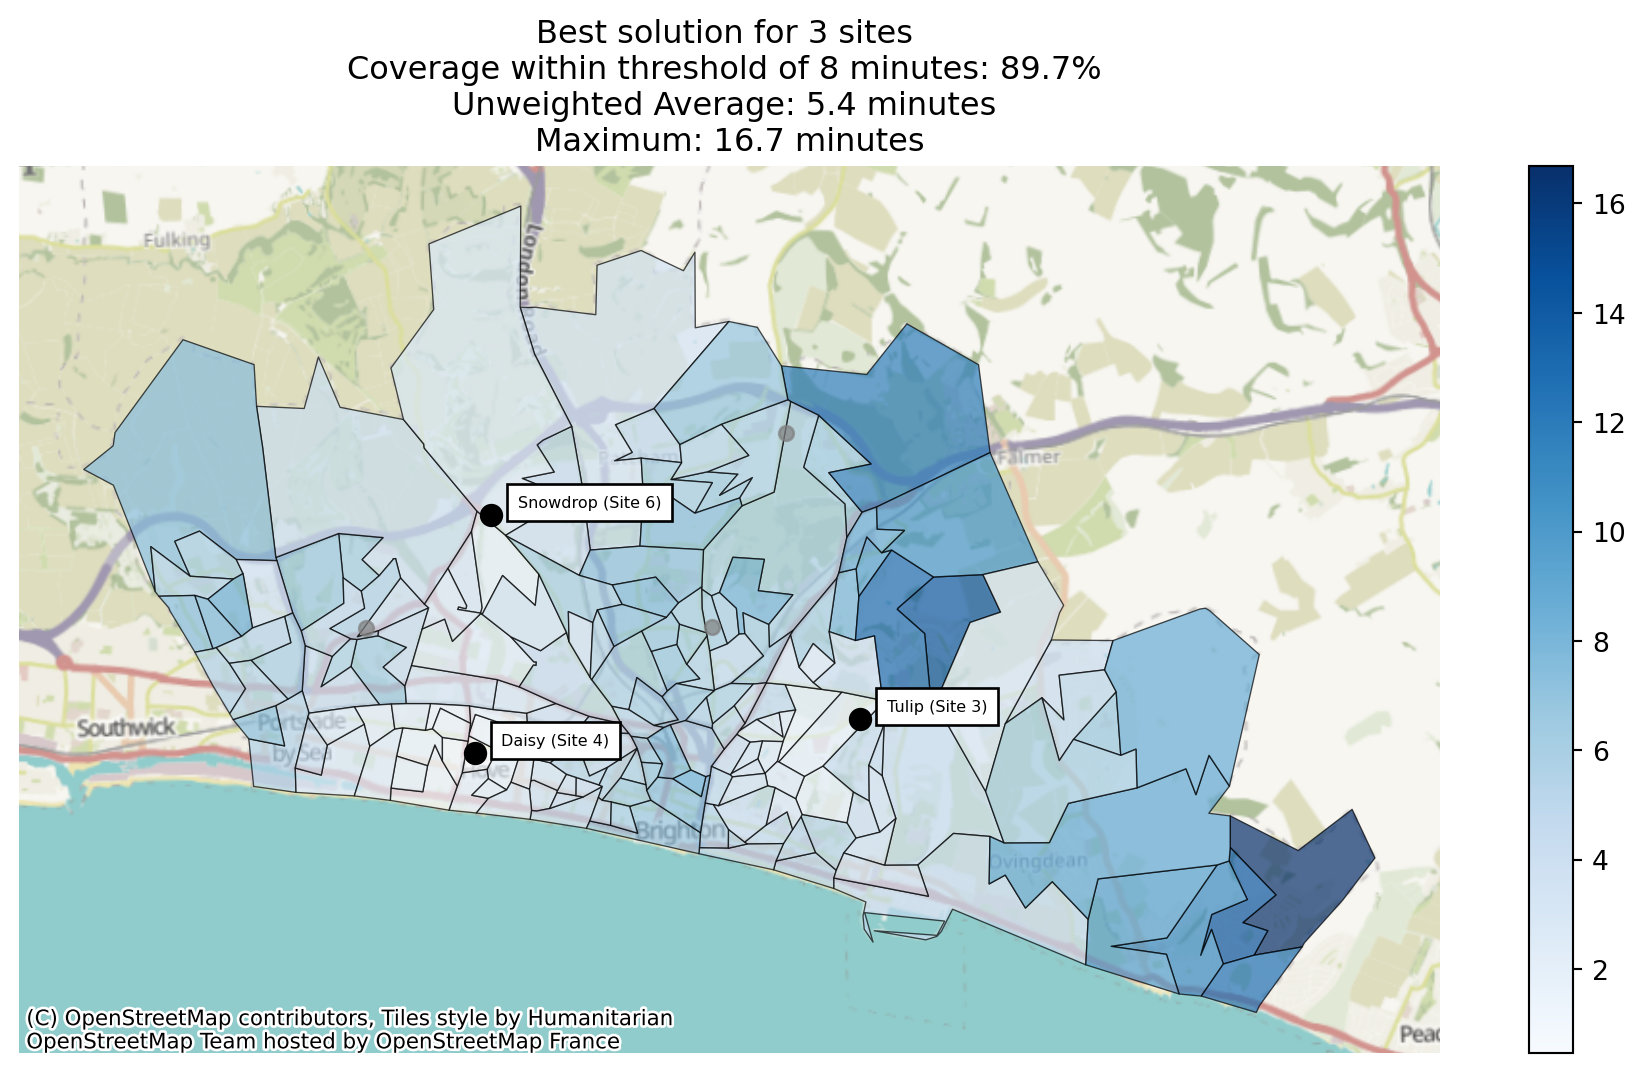

In [10]:
solution_small_greedy_mclp = problem_small.solve(p=3, search_strategy="greedy", objectives="mclp", threshold_for_coverage=8)
solution_small_greedy_mclp.plot_best_combination()

Interestingly, when we compare our MCLP problem (maximising coverage location problem) and p-center (minimising the maximum travel distance), we end up with the same result, but the order the sites were added in changed! 

For MCLP, the best single-site combination is site index 5 (which corresponds to site 6 due to Python's zero indexing), with site indices 2 and 3 being added in the second and third pass respectively. 

In contrast, for p-center, it's site index 2 (corresponding to site 3 - Tulip) that's the best for a single site solution. 

## Greedy search on a larger problem

For the problem we've been working with so far, greedy search isn't really that useful as there are a small enough number of sites that for any value of p, we can brute force (evaluate every single possible combination) without difficulty. 

The value of the greedy search becomes much more apparent when we look at a bigger problem. 

In [11]:
problem = SiteProblem()

problem.add_demand("https://github.com/health-data-science-OR/healthcare-logistics/blob/master/optimisation/data/sh_demand.csv", demand_col="n_patients", location_id_col="sector")
problem.add_travel_matrix("https://github.com/health-data-science-OR/healthcare-logistics/blob/master/optimisation/data/clinic_car_travel_time.csv", source_col="sector")

In [12]:
problem.total_n_sites

With a total of 28 sites, if we were to solve for 10 sites, we would need to evaluate...

In [13]:
print(f"{int(math.factorial(30)/(math.factorial(30-10) * math.factorial(10))):,d}")

30,045,015


sites. That's a lot of sites!

However, using the greedy algorithm, we can get a solution we can be reasonably confident is somewhat decent fairly quickly. 

While we can't pass in a maximum travel time threshold for our greedy algorithm, we can pass in the `threshold_for_coverage` parameter to calculate the proportion of demand that meets a given target travel time (or the proportion of regions, via the `proportion_regions_within_coverage_threshold` column). 

In [14]:
solution_greedy = problem.solve(p=10, search_strategy="greedy", threshold_for_coverage=10)
solution_greedy

C:\lokigi\lokigi\site.py:1442: UserWarning: No candidate site dataframe was given.
Sites names have been taken from the columns of your travel matrix: clinic_1, clinic_2, clinic_3, clinic_4, clinic_5, clinic_6, clinic_7, clinic_8, clinic_9, clinic_10, clinic_11, clinic_12, clinic_13, clinic_14, clinic_15, clinic_16, clinic_17, clinic_18, clinic_19, clinic_20, clinic_21, clinic_22, clinic_23, clinic_24, clinic_25, clinic_26, clinic_27, clinic_28.
If you wish to override this, run .add_sites() to add your site dataframe before running .solve() again.
You can use the .show_sites_format() to see the expected format beforehand.
  warn(


  0%|          | 0/10 [00:00<?, ?it/s]

Best combination for 1 sites: [3]
Best combination for 2 sites: [3, 7]


Best combination for 3 sites: [3, 7, 11]
Best combination for 4 sites: [3, 4, 7, 11]


Best combination for 5 sites: [3, 4, 7, 8, 11]


Best combination for 6 sites: [3, 4, 7, 8, 10, 11]


Best combination for 7 sites: [3, 4, 7, 8, 10, 11, 22]


Best combination for 8 sites: [3, 4, 7, 8, 10, 11, 17, 22]


Best combination for 9 sites: [3, 4, 7, 8, 10, 11, 17, 22, 24]


Best combination for 10 sites: [3, 4, 7, 8, 10, 11, 15, 17, 22, 24]


In [15]:
solution_greedy.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[clinic_4, clinic_5, clinic_8, clinic_9, clini...","[3, 4, 7, 8, 10, 11, 15, 17, 22, 24]",10,6.81,10.0,19.43,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...


## GRASP

As we can see from the above, while we can now tackle much larger problems than before, we get a single deterministic output from the greedy search problem. This isn't ideal - we can't provide multiple near-optimum solutions to our stakeholders, and we have no idea how good our solution is - is it stuck in a local optimum a long way from the global optimum? 

Enter GRASP - Greedy Randomised Adaptive Search Procedure. 

In [16]:
solution = problem.solve(p=10, search_strategy="grasp", threshold_for_coverage=10)


Finding 5 diverse solutions (max 100 attempts):   0%|          | 0/5 [00:00<?, ?it/s]

Finding 5 diverse solutions (max 100 attempts):  20%|██        | 1/5 [00:00<00:02,  1.56it/s]

Finding 5 diverse solutions (max 100 attempts):  40%|████      | 2/5 [00:02<00:04,  1.36s/it]

Finding 5 diverse solutions (max 100 attempts):  60%|██████    | 3/5 [00:04<00:03,  1.66s/it]

Finding 5 diverse solutions (max 100 attempts):  80%|████████  | 4/5 [00:07<00:02,  2.01s/it]

Finding 5 diverse solutions (max 100 attempts): 100%|██████████| 5/5 [00:09<00:00,  2.20s/it]

Finding 5 diverse solutions (max 100 attempts): 100%|██████████| 5/5 [00:09<00:00,  1.92s/it]

In [17]:
solution.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 10, 11, 15, 17, 22, 24]",10,6.79,9.89,18.68,32.37,0.62,sector sector_x clinic_4 clinic_5 clini...
1,2,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 9, 11, 12, 17, 22, 24]",10,6.86,10.09,20.35,32.37,0.62,sector sector_x clinic_4 clinic_5 clini...
2,3,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 9, 11, 12, 17, 22, 27]",10,6.88,10.06,20.11,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
3,4,"[clinic_1, clinic_5, clinic_6, clinic_9, clini...","[0, 4, 5, 8, 9, 11, 12, 17, 22, 27]",10,6.91,10.21,20.11,32.37,0.60,sector sector_x clinic_1 clinic_5 clini...
4,5,"[clinic_1, clinic_5, clinic_8, clinic_9, clini...","[0, 4, 7, 8, 9, 10, 11, 17, 22, 27]",10,7.00,10.38,20.58,32.37,0.58,sector sector_x clinic_1 clinic_5 clini...


Let's compare this to the best solution found by the pure greedy algorithm:

In [18]:
solution_greedy.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[clinic_4, clinic_5, clinic_8, clinic_9, clini...","[3, 4, 7, 8, 10, 11, 15, 17, 22, 24]",10,6.81,10.0,19.43,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...


Interestingly this doesn't show up in our top 5 solutions found with GRASP, and is between the top two solutions that were found! So it's worth considering whether to run both. 

We can try to run GRASP with a higher number of maximum iterations and a slightly higher alpha to get a more diverse solution pool. In the interests of it not taking forever to regenerate this documentation, below we show a screenshot of the outputs when we've run GRASP for much longer.  

In [19]:
solution_grasp_big = problem.solve(
    p=10, search_strategy="grasp", threshold_for_coverage=10, grasp_alpha=0.6,
    grasp_max_attempts=50000, grasp_num_solutions=50
    )

Finding 50 diverse solutions (max 50000 attempts):   0%|          | 0/50 [00:00<?, ?it/s]

Finding 50 diverse solutions (max 50000 attempts):   2%|▏         | 1/50 [00:00<00:31,  1.53it/s]

Finding 50 diverse solutions (max 50000 attempts):   4%|▍         | 2/50 [00:02<01:18,  1.63s/it]

Finding 50 diverse solutions (max 50000 attempts):   6%|▌         | 3/50 [00:04<01:22,  1.75s/it]

Finding 50 diverse solutions (max 50000 attempts):   8%|▊         | 4/50 [00:05<00:59,  1.30s/it]

...

Finding 50 diverse solutions (max 50000 attempts):  94%|█████████▍| 47/50 [01:48<00:04,  1.63s/it]

Finding 50 diverse solutions (max 50000 attempts):  96%|█████████▌| 48/50 [01:49<00:02,  1.28s/it]

Finding 50 diverse solutions (max 50000 attempts):  98%|█████████▊| 49/50 [01:52<00:02,  2.05s/it]

Finding 50 diverse solutions (max 50000 attempts): 100%|██████████| 50/50 [01:55<00:00,  2.31s/it]

Finding 50 diverse solutions (max 50000 attempts): 100%|██████████| 50/50 [01:55<00:00,  2.32s/it]

In [20]:
solution_grasp_big.show_solutions().head(10)

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 10, 11, 15, 17, 22, 24]",10,6.79,9.89,18.68,32.37,0.62,sector sector_x clinic_4 clinic_5 clini...
1,2,"[clinic_4, clinic_5, clinic_8, clinic_9, clini...","[3, 4, 7, 8, 10, 11, 15, 17, 22, 24]",10,6.81,10.00,19.43,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
2,3,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 10, 11, 15, 17, 22, 27]",10,6.82,9.89,18.21,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
3,4,"[clinic_2, clinic_4, clinic_5, clinic_6, clini...","[1, 3, 4, 5, 8, 10, 11, 15, 17, 22]",10,6.82,9.90,18.30,32.37,0.61,sector sector_x clinic_2 clinic_4 clini...
4,5,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 10, 11, 14, 17, 22, 24]",10,6.83,9.88,19.45,32.37,0.62,sector sector_x clinic_4 clinic_5 clini...
5,6,"[clinic_4, clinic_5, clinic_7, clinic_8, clini...","[3, 4, 6, 7, 8, 10, 11, 17, 22, 24]",10,6.83,10.09,20.08,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
6,7,"[clinic_1, clinic_4, clinic_5, clinic_6, clini...","[0, 3, 4, 5, 8, 10, 11, 17, 22, 27]",10,6.84,10.06,20.11,32.37,0.60,sector sector_x clinic_1 clinic_4 clini...
7,8,"[clinic_1, clinic_2, clinic_4, clinic_5, clini...","[0, 1, 3, 4, 5, 8, 10, 11, 17, 22]",10,6.84,10.08,20.11,32.37,0.60,sector sector_x clinic_1 clinic_2 clini...
8,9,"[clinic_4, clinic_5, clinic_8, clinic_9, clini...","[3, 4, 7, 8, 10, 11, 14, 17, 22, 24]",10,6.84,9.95,19.53,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
9,10,"[clinic_4, clinic_5, clinic_6, clinic_8, clini...","[3, 4, 5, 7, 8, 10, 11, 17, 22, 24]",10,6.85,10.14,20.44,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...


### Other GRASP parameters

We can change the number of sites that must differ to force a more diverse pool of solutions. 

In [21]:
solution_grasp_big_more_diverse = problem.solve(
    p=10, search_strategy="grasp", threshold_for_coverage=10, grasp_alpha=0.6,
    grasp_max_attempts=50000, grasp_num_solutions=30,
    grasp_min_sites_different=4, # set this value - default is 1
    )

Finding 30 diverse solutions (max 50000 attempts):   0%|          | 0/30 [00:00<?, ?it/s]

Finding 30 diverse solutions (max 50000 attempts):   3%|▎         | 1/30 [00:00<00:21,  1.38it/s]

Finding 30 diverse solutions (max 50000 attempts):   7%|▋         | 2/30 [00:03<00:47,  1.69s/it]

Finding 30 diverse solutions (max 50000 attempts):  10%|█         | 3/30 [00:05<00:49,  1.83s/it]

Finding 30 diverse solutions (max 50000 attempts):  13%|█▎        | 4/30 [00:07<00:51,  1.97s/it]

...

Finding 30 diverse solutions (max 50000 attempts):  90%|█████████ | 27/30 [01:49<00:12,  4.03s/it]

Finding 30 diverse solutions (max 50000 attempts):  93%|█████████▎| 28/30 [01:52<00:07,  3.77s/it]

Finding 30 diverse solutions (max 50000 attempts):  97%|█████████▋| 29/30 [02:07<00:07,  7.14s/it]

Finding 30 diverse solutions (max 50000 attempts): 100%|██████████| 30/30 [02:11<00:00,  6.34s/it]

Finding 30 diverse solutions (max 50000 attempts): 100%|██████████| 30/30 [02:11<00:00,  4.39s/it]

In [22]:
solution_grasp_big_more_diverse.show_solutions().head(10)

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[clinic_4, clinic_5, clinic_7, clinic_8, clini...","[3, 4, 6, 7, 8, 10, 11, 17, 22, 24]",10,6.83,10.09,20.08,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
1,2,"[clinic_1, clinic_4, clinic_5, clinic_6, clini...","[0, 3, 4, 5, 8, 10, 11, 17, 22, 27]",10,6.84,10.06,20.11,32.37,0.60,sector sector_x clinic_1 clinic_4 clini...
2,3,"[clinic_4, clinic_5, clinic_6, clinic_9, clini...","[3, 4, 5, 8, 9, 11, 12, 17, 22, 24]",10,6.86,10.09,20.35,32.37,0.62,sector sector_x clinic_4 clinic_5 clini...
3,4,"[clinic_1, clinic_2, clinic_3, clinic_5, clini...","[0, 1, 2, 4, 6, 8, 10, 11, 17, 22]",10,6.98,10.20,20.12,32.37,0.59,sector sector_x clinic_1 clinic_2 clini...
4,5,"[clinic_2, clinic_4, clinic_5, clinic_6, clini...","[1, 3, 4, 5, 8, 10, 11, 15, 22, 24]",10,7.04,10.48,18.62,32.37,0.56,sector sector_x clinic_2 clinic_4 clini...
5,6,"[clinic_1, clinic_2, clinic_5, clinic_8, clini...","[0, 1, 4, 7, 8, 10, 11, 13, 14, 22]",10,7.07,10.17,18.66,32.37,0.59,sector sector_x clinic_1 clinic_2 clini...
6,7,"[clinic_3, clinic_5, clinic_6, clinic_9, clini...","[2, 4, 5, 8, 10, 11, 13, 14, 22, 24]",10,7.08,10.06,19.45,32.37,0.63,sector sector_x clinic_3 clinic_5 clini...
7,8,"[clinic_1, clinic_3, clinic_5, clinic_8, clini...","[0, 2, 4, 7, 11, 12, 17, 21, 22, 24]",10,7.17,10.47,20.58,32.37,0.58,sector sector_x clinic_1 clinic_3 clini...
8,9,"[clinic_4, clinic_5, clinic_6, clinic_7, clini...","[3, 4, 5, 6, 10, 11, 13, 21, 22, 27]",10,7.18,10.12,19.96,32.37,0.60,sector sector_x clinic_4 clinic_5 clini...
9,10,"[clinic_1, clinic_2, clinic_5, clinic_7, clini...","[0, 1, 4, 6, 7, 8, 9, 11, 12, 17]",10,7.22,10.87,22.03,32.37,0.56,sector sector_x clinic_1 clinic_2 clini...


We can also change the chance of a local search taking place.

In [23]:
solution_grasp_less_local_searching = problem.solve(
    p=10, search_strategy="grasp", threshold_for_coverage=10, grasp_alpha=0.6,
    grasp_max_attempts=50000, grasp_num_solutions=20,
    grasp_local_search_chance=0.4 # set this value - default is 0.8
    )

Finding 20 diverse solutions (max 50000 attempts):   0%|          | 0/20 [00:00<?, ?it/s]

Finding 20 diverse solutions (max 50000 attempts):   5%|▌         | 1/20 [00:00<00:12,  1.57it/s]

Finding 20 diverse solutions (max 50000 attempts):  10%|█         | 2/20 [00:01<00:10,  1.70it/s]

Finding 20 diverse solutions (max 50000 attempts):  15%|█▌        | 3/20 [00:02<00:19,  1.14s/it]

Finding 20 diverse solutions (max 50000 attempts):  20%|██        | 4/20 [00:03<00:15,  1.02it/s]

...

Finding 20 diverse solutions (max 50000 attempts):  85%|████████▌ | 17/20 [00:17<00:02,  1.02it/s]

Finding 20 diverse solutions (max 50000 attempts):  90%|█████████ | 18/20 [00:19<00:02,  1.30s/it]

Finding 20 diverse solutions (max 50000 attempts):  95%|█████████▌| 19/20 [00:21<00:01,  1.59s/it]

Finding 20 diverse solutions (max 50000 attempts): 100%|██████████| 20/20 [00:22<00:00,  1.26s/it]

Finding 20 diverse solutions (max 50000 attempts): 100%|██████████| 20/20 [00:22<00:00,  1.12s/it]

And we can also change the maximum number of swaps that will happen in the local search stage, ensuring a diverse range of solutions is explored, which is particularly important for larger questions. 

In [24]:
solution_grasp_less_local_searching = problem.solve(
    p=10, search_strategy="grasp", threshold_for_coverage=10, grasp_alpha=0.6,
    grasp_max_attempts=50000, grasp_num_solutions=20,
    grasp_max_swap_count_local_search=50 # set this value - default is 10
    )

Finding 20 diverse solutions (max 50000 attempts):   0%|          | 0/20 [00:00<?, ?it/s]

Finding 20 diverse solutions (max 50000 attempts):   5%|▌         | 1/20 [00:00<00:11,  1.62it/s]

Finding 20 diverse solutions (max 50000 attempts):  10%|█         | 2/20 [00:04<00:44,  2.46s/it]

Finding 20 diverse solutions (max 50000 attempts):  15%|█▌        | 3/20 [00:05<00:35,  2.08s/it]

Finding 20 diverse solutions (max 50000 attempts):  20%|██        | 4/20 [00:11<00:52,  3.26s/it]

...

Finding 20 diverse solutions (max 50000 attempts):  85%|████████▌ | 17/20 [01:06<00:10,  3.42s/it]

Finding 20 diverse solutions (max 50000 attempts):  90%|█████████ | 18/20 [01:19<00:12,  6.08s/it]

Finding 20 diverse solutions (max 50000 attempts):  95%|█████████▌| 19/20 [01:21<00:05,  5.04s/it]

Finding 20 diverse solutions (max 50000 attempts): 100%|██████████| 20/20 [01:27<00:00,  5.31s/it]

Finding 20 diverse solutions (max 50000 attempts): 100%|██████████| 20/20 [01:27<00:00,  4.39s/it]

### GRASP on our smaller problem - does it find the known optimal solution in this case? 

Let's also try this out on our smaller problem from earlier - do we find the optimal solution here too?

In [25]:
solution_small_grasp = problem_small.solve(p=3, search_strategy="grasp")

Finding 5 diverse solutions (max 20 attempts):   0%|          | 0/5 [00:00<?, ?it/s]

Finding 5 diverse solutions (max 20 attempts):  40%|████      | 2/5 [00:00<00:00, 24.70it/s]


C:\lokigi\lokigi\site.py:1641: UserWarning: GRASP exhausted attempt budget (20 attempts) before finding 5 sufficiently diverse solutions. Returning 2 solutions.
  outputs = self._grasp(


In [26]:
solution_small_grasp.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,2,"[Tulip (Site 3), Daisy (Site 4), Daffodil (Sit...","[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...


<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

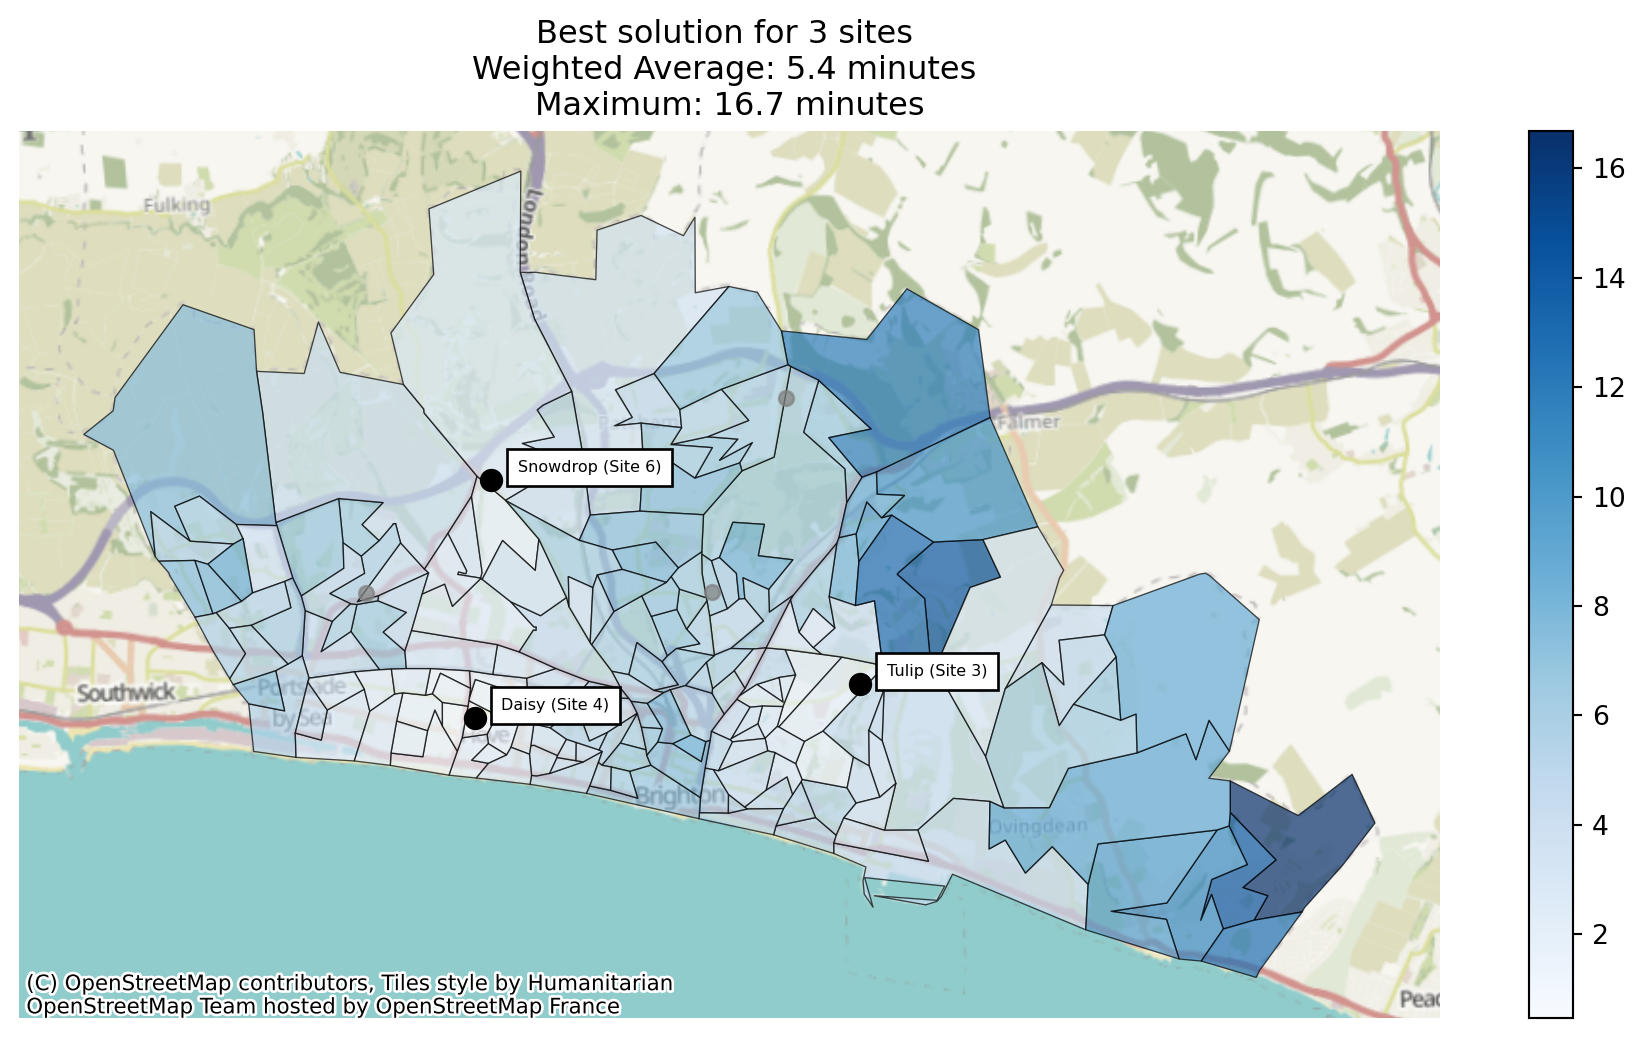

In [27]:
solution_small_grasp.plot_best_combination()

It gets quite stuck with the default alpha value, finding only two solutions! Let's turn up the alpha and see if we can get some more varied solutions out. 

In [28]:
solution_small_grasp_higher_alpha = problem_small.solve(
    p=3, search_strategy="grasp",
    grasp_alpha=0.4, grasp_max_attempts=500
    )

Finding 5 diverse solutions (max 500 attempts):   0%|          | 0/5 [00:00<?, ?it/s]

Finding 5 diverse solutions (max 500 attempts):  40%|████      | 2/5 [00:00<00:00, 18.52it/s]


C:\lokigi\lokigi\site.py:1641: UserWarning: GRASP exhausted attempt budget (500 attempts) before finding 5 sufficiently diverse solutions. Returning 2 solutions.
  outputs = self._grasp(


In [29]:
solution_small_grasp_higher_alpha.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,2,"[Tulip (Site 3), Daisy (Site 4), Daffodil (Sit...","[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...


It looks like we need to make our alpha higher again!

In [30]:
solution_small_grasp_even_higher_alpha = problem_small.solve(
    p=3, search_strategy="grasp",
    grasp_alpha=0.6, grasp_max_attempts=100000,
    grasp_min_sites_different=1
    )

Finding 5 diverse solutions (max 100000 attempts):   0%|          | 0/5 [00:00<?, ?it/s]

Finding 5 diverse solutions (max 100000 attempts):  60%|██████    | 3/5 [00:00<00:00, 26.20it/s]

Finding 5 diverse solutions (max 100000 attempts): 100%|██████████| 5/5 [00:00<00:00, 39.84it/s]

In [31]:
solution_small_grasp_even_higher_alpha.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,2,"[Tulip (Site 3), Daisy (Site 4), Daffodil (Sit...","[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...
2,3,"[Begonia (Site 2), Tulip (Site 3), Daisy (Site...","[1, 2, 3]",None,5.59,5.59,9.00,16.69,0.0,LSOA L...
3,4,"[Begonia (Site 2), Daisy (Site 4), Snowdrop (S...","[1, 3, 5]",None,6.64,6.64,11.58,22.86,0.0,LSOA L...
4,5,"[Daisy (Site 4), Daffodil (Site 5), Snowdrop (...","[3, 4, 5]",None,6.73,6.73,12.26,21.71,0.0,LSOA L...


Let's compare this with the best solutions from the brute force approach. 

In [32]:
solution_small_brute_force.show_solutions().head(15)

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,2,"[Tulip (Site 3), Daisy (Site 4), Daffodil (Sit...","[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...
2,3,"[Begonia (Site 2), Tulip (Site 3), Daisy (Site...","[1, 2, 3]",None,5.59,5.59,9.00,16.69,0.0,LSOA L...
3,4,"[Dahlia (Site 1), Tulip (Site 3), Daisy (Site 4)]","[0, 2, 3]",None,5.67,5.67,9.36,16.69,0.0,LSOA L...
4,5,"[Dahlia (Site 1), Tulip (Site 3), Snowdrop (Si...","[0, 2, 5]",None,6.21,6.21,9.33,16.69,0.0,LSOA L...
5,6,"[Tulip (Site 3), Daffodil (Site 5), Snowdrop (...","[2, 4, 5]",None,6.29,6.29,9.26,16.69,0.0,LSOA L...
6,7,"[Begonia (Site 2), Tulip (Site 3), Snowdrop (S...","[1, 2, 5]",None,6.31,6.31,9.45,16.69,0.0,LSOA L...
7,8,"[Dahlia (Site 1), Tulip (Site 3), Daffodil (Si...","[0, 2, 4]",None,6.32,6.32,9.70,16.69,0.0,LSOA L...
8,9,"[Dahlia (Site 1), Begonia (Site 2), Tulip (Sit...","[0, 1, 2]",None,6.39,6.39,9.77,16.69,0.0,LSOA L...
9,10,"[Begonia (Site 2), Daisy (Site 4), Snowdrop (S...","[1, 3, 5]",None,6.64,6.64,11.58,22.86,0.0,LSOA L...


We can see it found the
- best
- second best
- 3rd best
- 10th best
- and 11th best solutions

Let's go with an even higher alpha and ask for it to find more solutions. 

In [33]:
solution_small_grasp_higher_alpha_more_sols = problem_small.solve(
    p=3, search_strategy="grasp",
    grasp_alpha=0.95, grasp_max_attempts=50000,
    grasp_num_solutions=20
    )

Finding 20 diverse solutions (max 50000 attempts):   0%|          | 0/20 [00:00<?, ?it/s]

Finding 20 diverse solutions (max 50000 attempts):  15%|█▌        | 3/20 [00:00<00:00, 23.47it/s]

Finding 20 diverse solutions (max 50000 attempts):  75%|███████▌  | 15/20 [00:01<00:00,  8.20it/s]


C:\lokigi\lokigi\site.py:1641: UserWarning: GRASP exhausted attempt budget (50000 attempts) before finding 20 sufficiently diverse solutions. Returning 15 solutions.
  outputs = self._grasp(


In [34]:
solution_small_grasp_higher_alpha_more_sols.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,2,"[Tulip (Site 3), Daisy (Site 4), Daffodil (Sit...","[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...
2,3,"[Begonia (Site 2), Tulip (Site 3), Daisy (Site...","[1, 2, 3]",None,5.59,5.59,9.00,16.69,0.0,LSOA L...
3,4,"[Dahlia (Site 1), Tulip (Site 3), Daisy (Site 4)]","[0, 2, 3]",None,5.67,5.67,9.36,16.69,0.0,LSOA L...
4,5,"[Dahlia (Site 1), Tulip (Site 3), Snowdrop (Si...","[0, 2, 5]",None,6.21,6.21,9.33,16.69,0.0,LSOA L...
5,6,"[Tulip (Site 3), Daffodil (Site 5), Snowdrop (...","[2, 4, 5]",None,6.29,6.29,9.26,16.69,0.0,LSOA L...
6,7,"[Begonia (Site 2), Tulip (Site 3), Snowdrop (S...","[1, 2, 5]",None,6.31,6.31,9.45,16.69,0.0,LSOA L...
7,8,"[Dahlia (Site 1), Tulip (Site 3), Daffodil (Si...","[0, 2, 4]",None,6.32,6.32,9.70,16.69,0.0,LSOA L...
8,9,"[Dahlia (Site 1), Begonia (Site 2), Tulip (Sit...","[0, 1, 2]",None,6.39,6.39,9.77,16.69,0.0,LSOA L...
9,10,"[Begonia (Site 2), Daisy (Site 4), Snowdrop (S...","[1, 3, 5]",None,6.64,6.64,11.58,22.86,0.0,LSOA L...


With an even higher alpha, we could choose to run for longer periods and be confident we're exploring a good range of the solution space without the computational overhead of the brute force method. 